In [5]:
import pandas as pd
import polars as pl

from Python import config, reliability

games = pl.read_parquet(config.PITCHER_GAMES_PATH)

dev = (
    games
    .filter(pl.col("season").is_in(config.FEATURE_RESEARCH_SEASONS))
    .filter(pl.col("PA") >= config.MIN_STARTER_BATTERS_FACED)
    .sort(["pitcher", "game_date"])
    .to_pandas()
)

assert set(dev["season"].unique()) == {2023, 2024}
assert dev["PA"].min() >= config.MIN_STARTER_BATTERS_FACED
assert pd.to_datetime(dev["game_date"]).max().year == 2024


In [6]:
plans = {
   "k_rate": [("K", "PA", True)],
   "bb_rate": [("BB", "PA", True)],
   "whiff_rate": [("Whiffs", "Swings", True)],
   "csw_rate": [("CSW", "Pitches", True)],
   "chase_rate": [("Chases", "OutZone", True)],
   "hr_fb": [("HR", "FB", True)],
}


In [8]:
curves = {
    "k_rate": reliability.stabilization_by_denominator(
        dev,
        plans["k_rate"],
        targets=range(25, 1001, 25),
        id_col="pitcher",
    ),
}
curves["k_rate"]

,K
25,0.210797
50,0.328391
75,0.464388
100,0.503969
125,0.604223
150,0.579271
175,0.571231
200,0.613219
225,0.654384
250,0.644862


In [10]:
print(curves["k_rate"].columns.tolist())
curves["k_rate"].head()

['K']


,K
25,0.210797
50,0.328391
75,0.464388
100,0.503969
125,0.604223


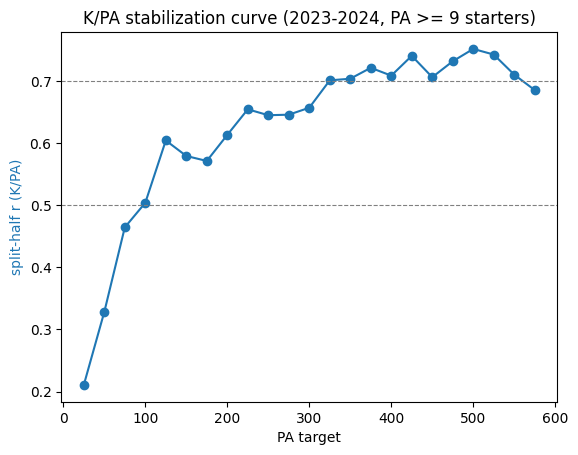

In [11]:
fig, ax1 = plt.subplots()
ax1.plot(curves["k_rate"].index, curves["k_rate"]["K"], color="tab:blue", marker="o")
ax1.set_xlabel("PA target")
ax1.set_ylabel("split-half r (K/PA)", color="tab:blue")
ax1.axhline(0.50, color="gray", linestyle="--", linewidth=0.8)
ax1.axhline(0.70, color="gray", linestyle="--", linewidth=0.8)
plt.title("K/PA stabilization curve (2023-2024, PA >= 9 starters)")
plt.show()

In [14]:
dev_sorted = dev.sort_values(["pitcher", "game_date"])
dev_sorted["cum_pa"] = dev_sorted.groupby("pitcher")["PA"].cumsum()

qualified_counts = {}
for target in range(25, 1001, 25):
    qualified_counts[target] = dev_sorted.loc[dev_sorted["cum_pa"] >= target, "pitcher"].nunique()

counts_df = pd.Series(qualified_counts, name="n_qualified_pitchers")
counts_df

25      387
50      358
75      344
100     321
125     307
150     289
175     275
200     259
225     254
250     241
275     232
300     224
325     217
350     208
375     197
400     190
425     187
450     181
475     176
500     173
525     162
550     154
575     149
600     145
625     140
650     135
675     131
700     126
725     122
750     118
775     115
800     111
825     107
850     101
875      97
900      94
925      92
950      88
975      83
1000     82
Name: n_qualified_pitchers, dtype: int64

In [16]:
total_pa_per_pitcher = dev.groupby("pitcher")["PA"].sum()
qualified_counts_strict = {}
for target in range(25, 1001, 25):
    qualified_counts_strict[target] = (total_pa_per_pitcher >= 2 * target).sum()

counts_strict_df = pd.Series(qualified_counts_strict, name="n_qualified_pitchers_strict")
print(counts_strict_df.to_string())

25      358
50      321
75      289
100     259
125     241
150     224
175     208
200     190
225     181
250     173
275     154
300     145
325     135
350     126
375     118
400     111
425     101
450      94
475      88
500      82
525      69
550      63
575      57
600      49
625      42
650      33
675      29
700      25
725      20
750      17
775      11
800       2
825       1
850       0
875       0
900       0
925       0
950       0
975       0
1000      0


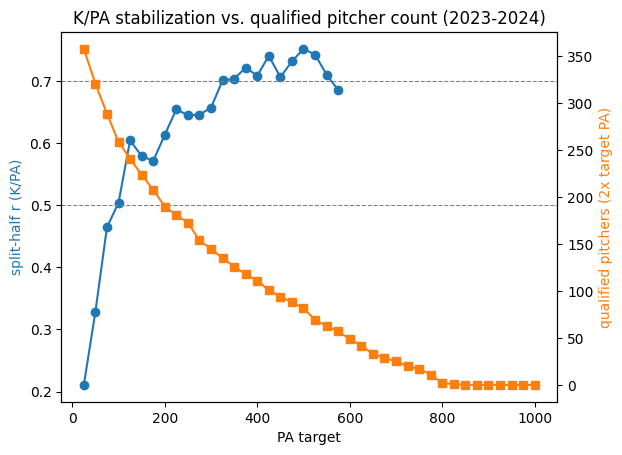

In [17]:
fig, ax1 = plt.subplots()
ax1.plot(curves["k_rate"].index, curves["k_rate"]["K"], color="tab:blue", marker="o", label="split-half r")
ax1.axhline(0.50, color="gray", linestyle="--", linewidth=0.8)
ax1.axhline(0.70, color="gray", linestyle="--", linewidth=0.8)
ax1.set_xlabel("PA target")
ax1.set_ylabel("split-half r (K/PA)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(counts_strict_df.index, counts_strict_df.values, color="tab:orange", marker="s", label="qualified pitchers")
ax2.set_ylabel("qualified pitchers (2x target PA)", color="tab:orange")

plt.title("K/PA stabilization vs. qualified pitcher count (2023-2024)")
plt.show()

In [18]:
import numpy as np

rng = np.random.default_rng(42)
pitchers = dev["pitcher"].unique()
n_boot = 300
targets_k = list(range(25, 1001, 25))

boot_results = np.full((n_boot, len(targets_k)), np.nan)

for b in range(n_boot):
    sample_pitchers = rng.choice(pitchers, size=len(pitchers), replace=True)
    boot_frames = []
    for i, pid in enumerate(sample_pitchers):
        sub = dev[dev["pitcher"] == pid].copy()
        sub["pitcher"] = i  # relabel to avoid duplicate-key collisions in the resample
        boot_frames.append(sub)
    boot_df = pd.concat(boot_frames, ignore_index=True)

    try:
        boot_curve = reliability.stabilization_by_denominator(
            boot_df,
            plans["k_rate"],
            targets=targets_k,
            id_col="pitcher",
            min_players=20,  # lowered for bootstrap resamples; see note below
        )
        for j, t in enumerate(targets_k):
            if t in boot_curve.index:
                boot_results[b, j] = boot_curve.loc[t, "K"]
    except Exception:
        continue

boot_df_results = pd.DataFrame(boot_results, columns=targets_k)
ci_lower = boot_df_results.quantile(0.025)
ci_upper = boot_df_results.quantile(0.975)
ci_median = boot_df_results.median()

ci_summary = pd.DataFrame({
    "median_r": ci_median,
    "ci_low": ci_lower,
    "ci_high": ci_upper,
    "n_valid_boots": boot_df_results.notna().sum(),
})
print(ci_summary.to_string())

      median_r    ci_low   ci_high  n_valid_boots
25    0.216180  0.119305  0.320752            300
50    0.331923  0.218550  0.424916            300
75    0.465502  0.361732  0.556892            300
100   0.504320  0.401909  0.594237            300
125   0.605998  0.521913  0.689895            300
150   0.578394  0.498500  0.660082            300
175   0.573638  0.469815  0.660656            300
200   0.617378  0.518440  0.706806            300
225   0.658774  0.564538  0.737365            300
250   0.650386  0.534883  0.730815            300
275   0.653759  0.519399  0.744906            300
300   0.662587  0.532120  0.752670            300
325   0.710329  0.577949  0.788809            300
350   0.710249  0.596028  0.785103            300
375   0.725753  0.620065  0.799579            300
400   0.716990  0.610866  0.795070            300
425   0.742330  0.649141  0.817886            300
450   0.708687  0.616378  0.791218            300
475   0.732955  0.630321  0.816588            300


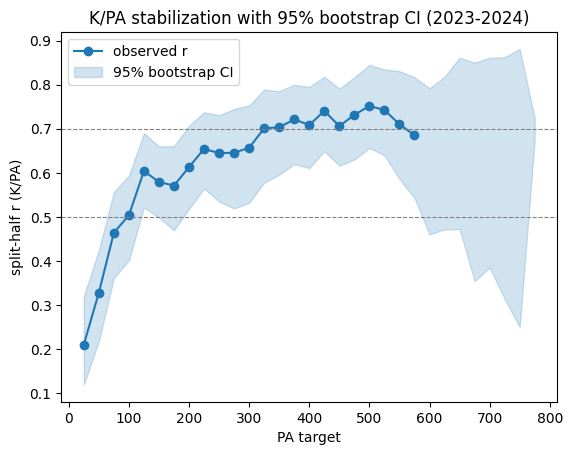

In [19]:
fig, ax1 = plt.subplots()
ax1.plot(curves["k_rate"].index, curves["k_rate"]["K"], color="tab:blue", marker="o", label="observed r")
ax1.fill_between(ci_summary.index, ci_summary["ci_low"], ci_summary["ci_high"],
                  color="tab:blue", alpha=0.2, label="95% bootstrap CI")
ax1.axhline(0.50, color="gray", linestyle="--", linewidth=0.8)
ax1.axhline(0.70, color="gray", linestyle="--", linewidth=0.8)
ax1.set_xlabel("PA target")
ax1.set_ylabel("split-half r (K/PA)")
ax1.legend()
plt.title("K/PA stabilization with 95% bootstrap CI (2023-2024)")
plt.show()

In [20]:
for thr in (0.50, 0.70):
    crossing_median = ci_summary[ci_summary["median_r"] >= thr].index.min()
    crossing_low = ci_summary[ci_summary["ci_low"] >= thr].index.min()
    crossing_high = ci_summary[ci_summary["ci_high"] >= thr].index.min()
    print(f"r={thr}: median crosses at PA={crossing_median}, "
          f"lower-CI crosses at PA={crossing_low}, upper-CI crosses at PA={crossing_high}")

r=0.5: median crosses at PA=100, lower-CI crosses at PA=125, upper-CI crosses at PA=75
r=0.7: median crosses at PA=325, lower-CI crosses at PA=nan, upper-CI crosses at PA=200
